In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import joblib

warnings.filterwarnings("ignore")

# Create folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../report/plots", exist_ok=True)
os.makedirs("../data/exports", exist_ok=True)

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

print("Phase 5 ML setup complete.")

Phase 5 ML setup complete.


In [2]:
# Load Phase 2 cleaned dataset
df = pd.read_csv("../data/processed/credit_risk_cleaned.csv", low_memory=False)

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)
print("Default rate:", round(df["target"].mean() * 100, 2), "%")

print("\nTarget counts:")
print(df["target"].value_counts())

print("\nColumn types:")
print(df.dtypes.value_counts())

df.head()

Cleaned dataset loaded successfully.
Shape: (1348070, 92)
Default rate: 19.98 %

Target counts:
target
0    1078713
1     269357
Name: count, dtype: int64

Column types:
int64      74
float64    18
Name: count, dtype: int64


,loan_amnt,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,3600.0,13.99,123.03,10.0,55000.0,5.91,0.0,7.0,0.0,2765.0,...,0,0,0,0,0,0,0,0,0,0
1,24700.0,11.99,820.28,10.0,65000.0,16.06,1.0,22.0,0.0,21470.0,...,1,0,0,0,0,0,0,0,0,0
2,20000.0,10.78,432.66,10.0,63000.0,10.78,0.0,6.0,0.0,7869.0,...,0,0,0,0,0,0,0,0,0,0
3,10400.0,22.45,289.91,3.0,104433.0,25.37,1.0,12.0,0.0,21929.0,...,0,0,0,0,0,0,0,0,0,0
4,11950.0,13.44,405.18,4.0,34000.0,10.20,0.0,5.0,0.0,8822.0,...,0,0,0,0,0,0,0,0,0,0


## Phase 5 Modeling Dataset

For machine learning, the cleaned and encoded Phase 2 dataset `credit_risk_cleaned.csv` was used. This dataset contains 1,348,070 rows and 92 columns, including the target variable.

The target distribution is moderately imbalanced, with approximately 80.02% good loans and 19.98% bad loans. All features are numeric, so the dataset is ready for train-test split, scaling, and model training.

In [3]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Feature matrix shape: (1348070, 91)
Target shape: (1348070,)
Train shape: (1078456, 91)
Test shape: (269614, 91)

Train target distribution:
target
0    80.019027
1    19.980973
Name: proportion, dtype: float64

Test target distribution:
target
0    80.019213
1    19.980787
Name: proportion, dtype: float64


## Train-Test Split

The dataset was split into training and testing sets using an 80:20 split. Stratified sampling was used to preserve the original target distribution in both sets.

Both training and testing data have approximately 19.98% default loans, which ensures that model evaluation is performed on a representative test set.

In [4]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for later app/model use
joblib.dump(scaler, "../models/scaler.pkl")

print("Feature scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Scaler saved to models/scaler.pkl")

Feature scaling complete.
X_train_scaled shape: (1078456, 91)
X_test_scaled shape: (269614, 91)
Scaler saved to models/scaler.pkl


## Feature Scaling

StandardScaler was used to scale all features before model training. The scaler was fitted only on the training data and then applied to the test data to avoid data leakage.

The fitted scaler was saved as `models/scaler.pkl` for reuse during model deployment and prediction.

In [5]:
# Model 1: Logistic Regression Baseline

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

# Evaluation metrics
lr_auc = roc_auc_score(y_test, lr_probs)
lr_f1 = f1_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds)
lr_recall = recall_score(y_test, lr_preds)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, lr_probs)
lr_ks = max(tpr_lr - fpr_lr)
lr_gini = 2 * lr_auc - 1

print("Logistic Regression Results")
print("AUC-ROC:", round(lr_auc, 4))
print("KS Stat:", round(lr_ks, 4))
print("Gini:", round(lr_gini, 4))
print("F1 Score:", round(lr_f1, 4))
print("Precision:", round(lr_precision, 4))
print("Recall:", round(lr_recall, 4))

print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=["Good Loan", "Default"]))

Logistic Regression Results
AUC-ROC: 0.715
KS Stat: 0.3122
Gini: 0.4299
F1 Score: 0.432
Precision: 0.3247
Recall: 0.6451

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.88      0.66      0.76    215743
     Default       0.32      0.65      0.43     53871

    accuracy                           0.66    269614
   macro avg       0.60      0.66      0.60    269614
weighted avg       0.77      0.66      0.69    269614



### Logistic Regression Baseline Results

Logistic Regression was used as the baseline model because it is simple, interpretable, and commonly used in credit risk modeling.

The model achieved an AUC-ROC score of 0.7150, KS statistic of 0.3122, and Gini score of 0.4299. The recall for default loans is 64.51%, meaning the model is able to identify a good portion of risky borrowers.

However, precision for default loans is 32.47%, which means that some good borrowers are also being flagged as risky. This is expected in imbalanced credit risk data when the model is adjusted to detect more defaults.

Overall, Logistic Regression provides a strong baseline for comparison with more advanced models such as Random Forest and XGBoost.

In [6]:
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

print("Logistic Regression model saved.")

Logistic Regression model saved.


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

# Evaluation metrics
rf_auc = roc_auc_score(y_test, rf_probs)
rf_f1 = f1_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_probs)
rf_ks = max(tpr_rf - fpr_rf)
rf_gini = 2 * rf_auc - 1

print("Random Forest Results")
print("AUC-ROC:", round(rf_auc, 4))
print("KS Stat:", round(rf_ks, 4))
print("Gini:", round(rf_gini, 4))
print("F1 Score:", round(rf_f1, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=["Good Loan", "Default"]))

Random Forest Results
AUC-ROC: 0.7176
KS Stat: 0.312
Gini: 0.4352
F1 Score: 0.431
Precision: 0.3173
Recall: 0.6718

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.89      0.64      0.74    215743
     Default       0.32      0.67      0.43     53871

    accuracy                           0.65    269614
   macro avg       0.60      0.66      0.59    269614
weighted avg       0.77      0.65      0.68    269614



### Random Forest Results

Random Forest was trained as a non-linear model to capture more complex relationships between borrower features and default risk.

The model achieved an AUC-ROC score of 0.7176, which is slightly higher than Logistic Regression. It also achieved a default recall of 67.18%, meaning it identifies more defaulters than the baseline model.

However, the precision for default loans is slightly lower at 31.73%, showing that the model flags more good loans as risky. Overall, Random Forest improves recall slightly but does not provide a major performance jump over Logistic Regression.

In [8]:
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved.")

Random Forest model saved.


In [9]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 15 Random Forest features:")
print(rf_importance.head(15))

rf_importance.to_csv("../report/rf_feature_importance.csv", index=False)

Top 15 Random Forest features:
                        feature  importance
21            sub_grade_encoded    0.213382
20                grade_encoded    0.176342
1                      int_rate    0.174437
19                   term_years    0.085265
13                     fico_avg    0.045737
15         loan_to_income_ratio    0.039795
5                           dti    0.033639
16  installment_to_income_ratio    0.030181
17                   issue_year    0.028907
12                     mort_acc    0.017803
2                   installment    0.017711
0                     loan_amnt    0.016023
4                    annual_inc    0.015880
23                home_MORTGAGE    0.014642
22  verification_status_encoded    0.013524


### Random Forest Feature Importance

Random Forest feature importance shows that `sub_grade_encoded`, `grade_encoded`, and `int_rate` are the most important predictors of default risk. This aligns with the EDA and SQL findings, where default rates increased sharply across worse loan grades and higher interest rates.

Other important features include `term_years`, `fico_avg`, `loan_to_income_ratio`, `dti`, and `installment_to_income_ratio`. These features represent borrower credit quality and repayment burden, which are key drivers of credit risk.

The consistency between EDA, SQL analytics, and model feature importance strengthens the reliability of the project findings.

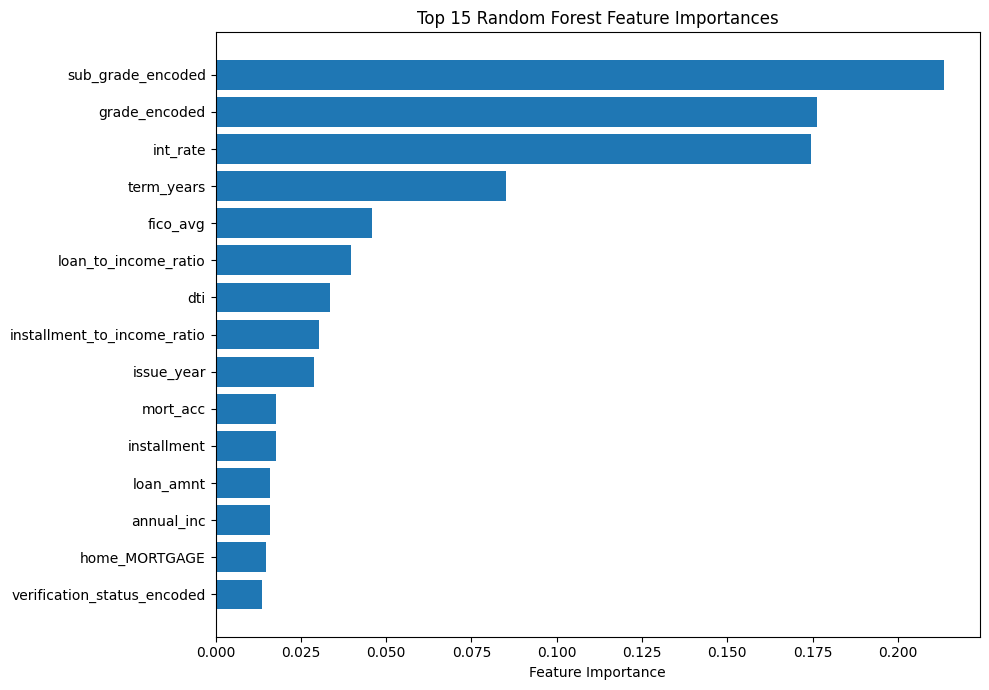

In [10]:
top_features = rf_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()

plt.savefig("../report/plots/11_rf_feature_importance.png", bbox_inches="tight")
plt.show()

In [11]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "AUC_ROC": [round(lr_auc, 4), round(rf_auc, 4)],
    "KS_Stat": [round(lr_ks, 4), round(rf_ks, 4)],
    "Gini": [round(lr_gini, 4), round(rf_gini, 4)],
    "F1_Score": [round(lr_f1, 4), round(rf_f1, 4)],
    "Precision": [round(lr_precision, 4), round(rf_precision, 4)],
    "Recall": [round(lr_recall, 4), round(rf_recall, 4)]
})

model_results

,Model,AUC_ROC,KS_Stat,Gini,F1_Score,Precision,Recall
0,Logistic Regression,0.7150,0.3122,0.4299,0.432,0.3247,0.6451
1,Random Forest,0.7176,0.3120,0.4352,0.431,0.3173,0.6718


### Model Comparison So Far

The initial model comparison shows that Random Forest slightly improves AUC-ROC compared to Logistic Regression, increasing from 0.7150 to 0.7176. Random Forest also has higher recall, meaning it identifies more default loans.

However, Logistic Regression has slightly better precision and F1 score. This means Random Forest captures more risky borrowers but also flags more good borrowers as risky.

Overall, both models show similar performance, and XGBoost will be trained next to check whether a boosting model can improve ranking power and predictive performance.

In [12]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is installed and ready.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is installed and ready.


In [13]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is installed and ready.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is installed and ready.


In [14]:
from xgboost import XGBClassifier

# Class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

# Model 3: XGBoost
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

# Evaluation metrics
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_probs)
xgb_ks = max(tpr_xgb - fpr_xgb)
xgb_gini = 2 * xgb_auc - 1

print("XGBoost Results")
print("AUC-ROC:", round(xgb_auc, 4))
print("KS Stat:", round(xgb_ks, 4))
print("Gini:", round(xgb_gini, 4))
print("F1 Score:", round(xgb_f1, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))

print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=["Good Loan", "Default"]))

scale_pos_weight: 4.0
XGBoost Results
AUC-ROC: 0.726
KS Stat: 0.3269
Gini: 0.452
F1 Score: 0.4396
Precision: 0.3255
Recall: 0.6769

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.89      0.65      0.75    215743
     Default       0.33      0.68      0.44     53871

    accuracy                           0.66    269614
   macro avg       0.61      0.66      0.60    269614
weighted avg       0.78      0.66      0.69    269614



### XGBoost Results

XGBoost was trained as the advanced boosting model for credit risk prediction. Since the dataset is imbalanced, `scale_pos_weight` was used to give higher importance to default loans during training.

The model achieved an AUC-ROC score of 0.7260, KS statistic of 0.3269, Gini score of 0.4520, and F1 score of 0.4396. It also achieved a default recall of 67.69%, meaning it identifies the highest proportion of defaulters among the models trained so far.

Compared to Logistic Regression and Random Forest, XGBoost provides the best overall performance and is currently the strongest model for this project.

In [15]:
joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("XGBoost model saved.")

XGBoost model saved.


In [16]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "AUC_ROC": [round(lr_auc, 4), round(rf_auc, 4), round(xgb_auc, 4)],
    "KS_Stat": [round(lr_ks, 4), round(rf_ks, 4), round(xgb_ks, 4)],
    "Gini": [round(lr_gini, 4), round(rf_gini, 4), round(xgb_gini, 4)],
    "F1_Score": [round(lr_f1, 4), round(rf_f1, 4), round(xgb_f1, 4)],
    "Precision": [round(lr_precision, 4), round(rf_precision, 4), round(xgb_precision, 4)],
    "Recall": [round(lr_recall, 4), round(rf_recall, 4), round(xgb_recall, 4)]
})

model_results.to_csv("../report/model_comparison.csv", index=False)

model_results

,Model,AUC_ROC,KS_Stat,Gini,F1_Score,Precision,Recall
0,Logistic Regression,0.7150,0.3122,0.4299,0.4320,0.3247,0.6451
1,Random Forest,0.7176,0.3120,0.4352,0.4310,0.3173,0.6718
2,XGBoost,0.7260,0.3269,0.4520,0.4396,0.3255,0.6769


### Final Model Comparison

The final model comparison shows that XGBoost performs the best among the three models. It achieved the highest AUC-ROC score of 0.7260, the highest KS statistic of 0.3269, and the highest Gini score of 0.4520.

XGBoost also achieved the highest default recall of 67.69%, meaning it identifies the largest proportion of actual default loans. Logistic Regression remains useful as an interpretable baseline, while Random Forest improves recall but does not outperform XGBoost overall.

Based on these results, XGBoost was selected as the best model for the credit risk prediction task.

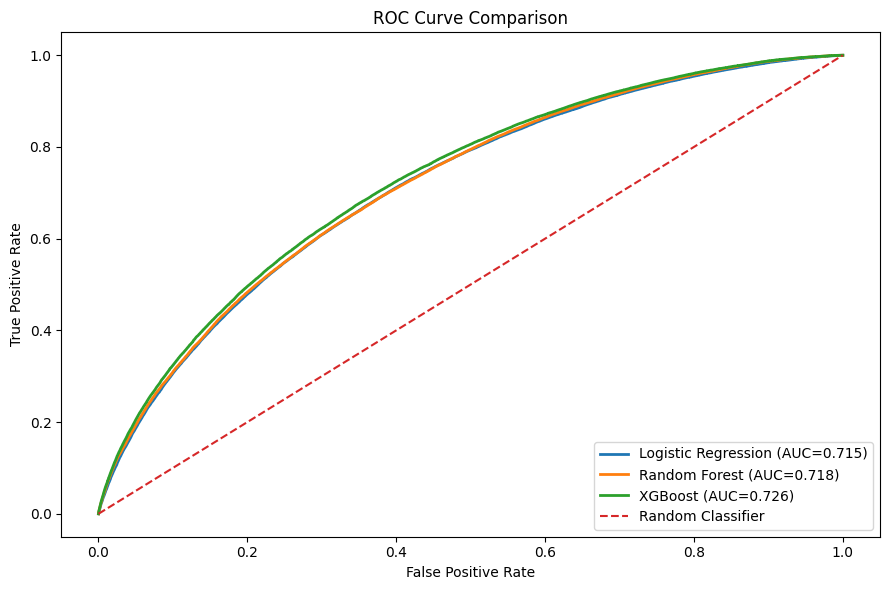

In [17]:
plt.figure(figsize=(9, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})", linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig("../report/plots/12_roc_curve_comparison.png", bbox_inches="tight")
plt.show()

### ROC Curve Comparison

The ROC curve comparison shows that all three models perform better than a random classifier. Among the models, XGBoost has the highest AUC-ROC score of 0.726, followed by Random Forest and Logistic Regression.

The curves are close to each other, but XGBoost provides the strongest ranking ability for distinguishing between good loans and default loans. Therefore, XGBoost is selected as the best-performing model for the next stage of the project.

In [18]:
xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 15 XGBoost features:")
print(xgb_importance.head(15))

xgb_importance.to_csv("../report/xgb_feature_importance.csv", index=False)

Top 15 XGBoost features:
                        feature  importance
20                grade_encoded    0.426085
21            sub_grade_encoded    0.240808
19                   term_years    0.039498
12                     mort_acc    0.016733
15         loan_to_income_ratio    0.016518
23                home_MORTGAGE    0.014104
5                           dti    0.012296
17                   issue_year    0.011551
27                    home_RENT    0.011159
13                     fico_avg    0.011086
22  verification_status_encoded    0.009353
18                  issue_month    0.008997
44                     state_CA    0.007855
16  installment_to_income_ratio    0.007293
38       purpose_small_business    0.007107


### XGBoost Feature Importance

XGBoost feature importance shows that `grade_encoded` and `sub_grade_encoded` are the strongest predictors of default risk. This confirms the earlier EDA and SQL findings that loan grade is one of the most important credit risk indicators.

Other important features include `term_years`, `loan_to_income_ratio`, `dti`, `fico_avg`, and home ownership indicators. These variables represent loan structure, borrower repayment burden, and borrower credit quality.

The consistency across EDA, SQL analysis, Random Forest importance, and XGBoost importance strengthens the reliability of the final model findings.

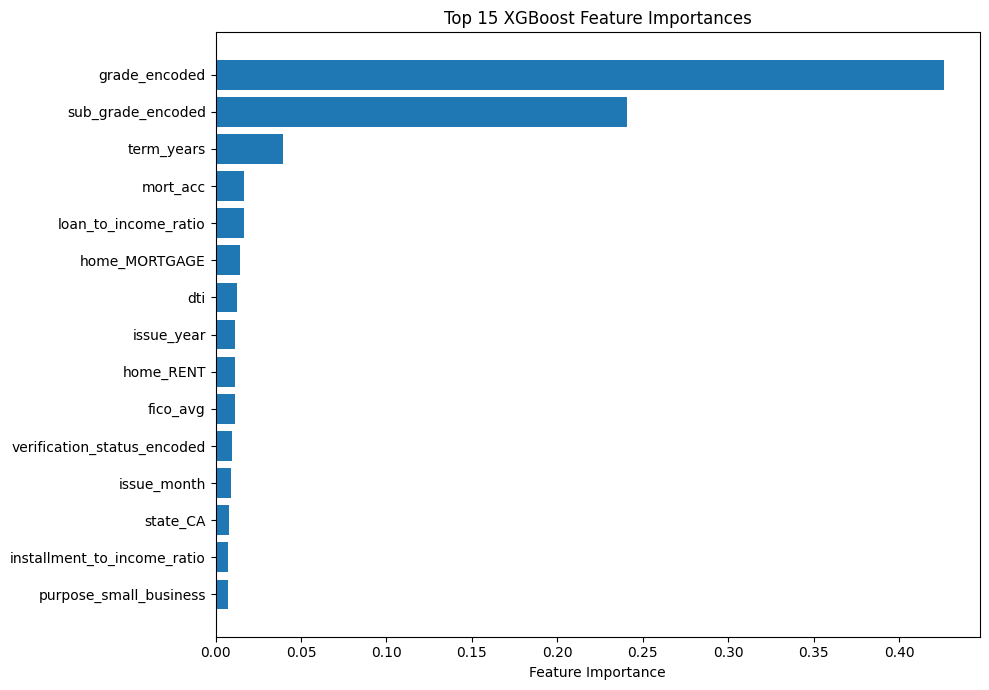

In [19]:
top_xgb_features = xgb_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_xgb_features["feature"], top_xgb_features["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()

plt.savefig("../report/plots/13_xgb_feature_importance.png", bbox_inches="tight")
plt.show()

In [20]:
# Save final best model and related artifacts

best_model = xgb_model

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_names.pkl")

print("Saved final model artifacts:")
print("models/best_model.pkl")
print("models/feature_names.pkl")

Saved final model artifacts:
models/best_model.pkl
models/feature_names.pkl


In [21]:
# Save test predictions for later scorecard / dashboard use

test_predictions = pd.DataFrame({
    "y_true": y_test.values,
    "xgb_default_probability": xgb_probs,
    "xgb_prediction": xgb_preds
})

test_predictions.to_csv("../data/exports/test_predictions.csv", index=False)

print("Saved test predictions:")
print("data/exports/test_predictions.csv")
print(test_predictions.head())

Saved test predictions:
data/exports/test_predictions.csv
   y_true  xgb_default_probability  xgb_prediction
0       0                 0.453659               0
1       0                 0.668521               1
2       0                 0.486845               0
3       0                 0.438225               0
4       0                 0.655751               1


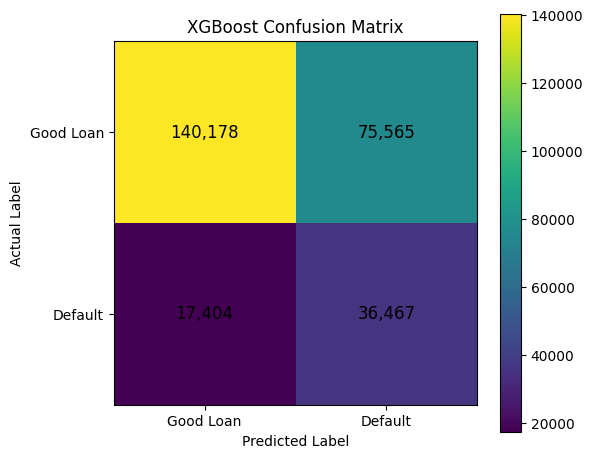

[[140178  75565]
 [ 17404  36467]]


In [22]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Good Loan", "Default"])
plt.yticks([0, 1], ["Good Loan", "Default"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)

plt.colorbar()
plt.tight_layout()

plt.savefig("../report/plots/14_xgb_confusion_matrix.png", bbox_inches="tight")
plt.show()

print(cm)

### XGBoost Confusion Matrix

The confusion matrix shows that the XGBoost model correctly identifies 36,467 default loans out of 53,871 actual defaults, giving a default recall of around 67.69%.

The model also incorrectly flags 75,565 good loans as defaults. In credit risk, this trade-off is expected because the model is designed to catch more risky borrowers, even if it means some good borrowers are flagged for manual review.

From a business perspective, this model is useful as a risk-screening tool because it helps identify a large portion of potential defaulters before loan approval.

## Phase 5 Machine Learning Summary

In Phase 5, three machine learning models were trained to predict loan default risk using the cleaned and encoded Phase 2 dataset.

The models trained were:

1. Logistic Regression
2. Random Forest
3. XGBoost

The dataset contained 1,348,070 rows and 91 input features after separating the target variable. The target distribution was moderately imbalanced, with approximately 80.02% good loans and 19.98% default loans. A stratified train-test split was used to preserve this distribution in both training and testing sets.

Feature scaling was performed using StandardScaler, fitted only on the training data to avoid data leakage. Logistic Regression and Random Forest were trained with class imbalance handling, while XGBoost used `scale_pos_weight`.

Final model comparison showed that XGBoost performed the best overall:

- AUC-ROC: 0.7260
- KS Statistic: 0.3269
- Gini: 0.4520
- F1 Score: 0.4396
- Precision: 0.3255
- Recall: 0.6769

XGBoost achieved the highest AUC, KS statistic, Gini score, F1 score, and default recall among the three models. Therefore, XGBoost was selected as the best model for the project.

Feature importance analysis showed that loan grade, sub-grade, interest rate, loan term, FICO score, DTI, loan-to-income ratio, and home ownership indicators are important drivers of default risk. These findings are consistent with the earlier EDA and SQL analysis.

The best model, scaler, feature names, model comparison table, feature importance files, ROC curve, confusion matrix, and test predictions were saved for later phases.